Verifica se all'interno del dataset sono presenti per le colonne  "content" e "content_commit_sha" valori NaN oppure sono vuote e in caso affermativo, eliminare l'intera riga poichè non avere informazioni sul content non è plausibile. Eliminazione anche delle righe che hanno nella colonna "content" un testo troppo corto (es. meno di 10 parole).

In [9]:
from pathlib import Path
import pandas as pd

cwd = Path.cwd()
candidate_paths = [
    cwd / "dataset" / "dataset.csv",
    cwd.parent / "dataset" / "dataset.csv",
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("dataset.csv not found in ./dataset or ../dataset")

df = pd.read_csv(data_path)

required_cols = ["content", "content_commit_sha"]
mask_missing = df[required_cols].isna().any(axis=1)
mask_empty = df[required_cols].astype(str).apply(lambda col: col.str.strip().eq(""), axis=0)
mask_empty_any = mask_empty.any(axis=1)
df_clean = df[~(mask_missing | mask_empty_any)].copy()

word_counts = df_clean["content"].astype(str).str.split().str.len()
df_clean = df_clean[word_counts >= 10].copy()

print(f"Rows before: {len(df)}, after cleaning: {len(df_clean)}")

Rows before: 2303, after cleaning: 2179


Realizzazione del barplot per vedere la distribuzione della variabile commit_count

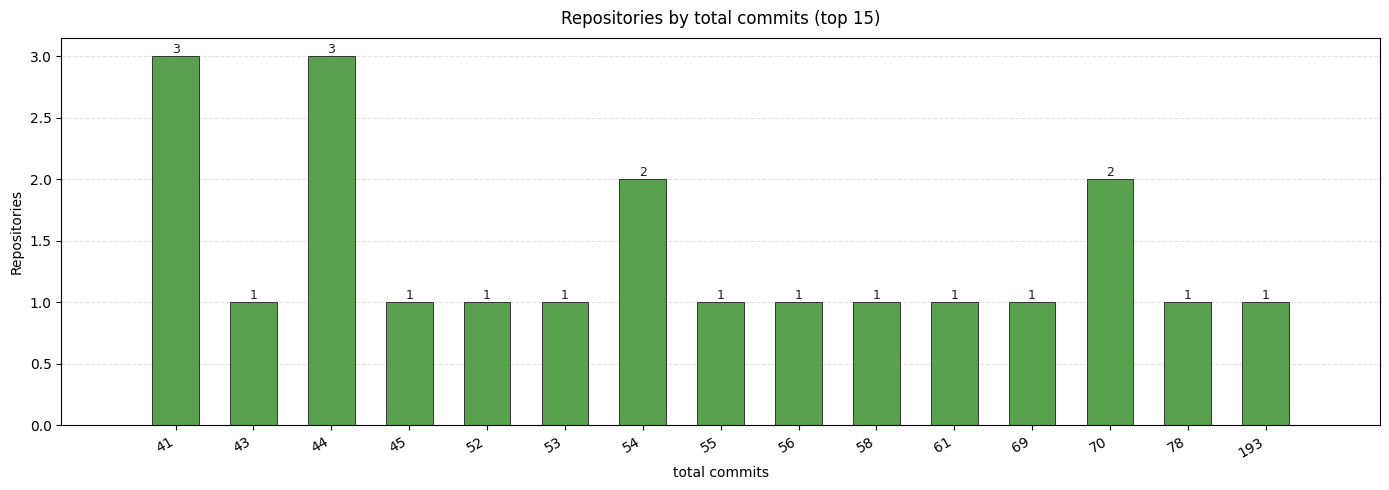

In [10]:
import matplotlib.pyplot as plt

TOP_N = 15  # show only the highest commit_count values

commit_count_num = pd.to_numeric(df_clean["commit_count"], errors="coerce")
row_counts = commit_count_num.dropna().astype(int).value_counts().sort_index()

if "repo_url" in df_clean.columns:
    repo_id = df_clean["repo_url"].astype(str)
else:
    repo_id = df_clean["repository_owner"].astype(str) + "/" + df_clean["repository_name"].astype(str)

repo_commit = (
    pd.DataFrame({"repo_id": repo_id, "commit_count": commit_count_num})
    .dropna(subset=["commit_count"])
    .groupby("repo_id")["commit_count"]
    .max()
 )
repo_counts = repo_commit.astype(int).value_counts().sort_index()

def top_by_commit(series, top_n):
    if series.empty or top_n is None or top_n <= 0:
        return series
    return series.iloc[-top_n:]

def barplot_counts(series, title, xlabel, ylabel, color):
    fig, ax = plt.subplots(figsize=(14, 5))
    x_labels = series.index.astype(int).astype(str)
    y = series.values
    positions = range(len(x_labels))
    bars = ax.bar(positions, y, color=color, edgecolor="#1f1f1f", linewidth=0.6, width=0.6)
    for rect, value in zip(bars, y):
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height(),
            str(value),
            ha="center",
            va="bottom",
            fontsize=9,
            color="#1f1f1f",
            clip_on=True,
        )
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_xticks(list(positions))
    ax.set_xticklabels(x_labels, rotation=30, ha="right")
    ax.margins(x=0.08)
    plt.tight_layout()


barplot_counts(
    top_by_commit(repo_counts, TOP_N),
    f"Repositories by total commits (top {TOP_N})",
    "total commits",
    "Repositories",
    "#59a14f",
)

Analisi della distribuzione del `commit_count` per repository direttamente dal dataset, per scegliere in modo informato la soglia di filtraggio.

In [11]:
commit_count_num = pd.to_numeric(df_clean["commit_count"], errors="coerce")

repo_commits = (
    pd.DataFrame({
        "repo_id": df_clean["repository_owner"] + "/" + df_clean["repository_name"],
        "commit_count": commit_count_num,
    })
    .dropna(subset=["commit_count"])
    .groupby("repo_id")["commit_count"]
    .max()
    .astype(int)
    .reset_index()
    .sort_values("commit_count", ascending=False)
    .reset_index(drop=True)
)

print(f"Repository totali: {len(repo_commits)}")
print(f"  min: {repo_commits['commit_count'].min()}")
print(f"  median: {int(repo_commits['commit_count'].median())}")
print(f"  max: {repo_commits['commit_count'].max()}")

Repository totali: 1897
  min: 1
  median: 2
  max: 193


Verifico se le colonne `file_path` e `filename` sono vuote nel dataset pulito.

In [12]:
cols = ["file_path", "filename"]
missing_cols = [col for col in cols if col not in df_clean.columns]

if missing_cols:
    print(f"Missing columns: {missing_cols}")
else:
    total_rows = len(df_clean)
    if total_rows == 0:
        print("No rows to check.")
    else:
        def is_empty(series):
            return series.isna() | series.astype(str).str.strip().eq("")

        empty_flags = df_clean[cols].apply(is_empty)
        for col in cols:
            empty_count = int(empty_flags[col].sum())
            print(f"{col}: empty {empty_count}/{total_rows} (all empty: {bool(empty_flags[col].all())})")

        both_empty = empty_flags.all(axis=1)
        print(f"Rows with both empty: {int(both_empty.sum())}/{total_rows}")
        print(f"All rows have both empty: {bool(both_empty.all())}")

file_path: empty 0/2179 (all empty: False)
filename: empty 0/2179 (all empty: False)
Rows with both empty: 0/2179
All rows have both empty: False


Analisi del numero di commit per repository ricavato direttamente dalla colonna `commit_count` del dataset.

Repository                                              commit_count
---------------------------------------------------------------------
MontrealAI/AGI-Alpha-Agent-v0                                    193
steipete/Peekaboo                                                 78
devill/refakts                                                    70
baleen37/dotfiles                                                 70
CIRISAI/CIRISAgent                                                69
zoedolan/Vybn                                                     61
evmts/guillotine                                                  58
BMPixel/cui                                                       56
UMEP-dev/SUEWS                                                    55
settlemint/asset-tokenization-kit                                 54
lbds137/tzurot                                                    54
bannzai/SwiftTUI                                                  53
kesslerio/attio-mcp-server       

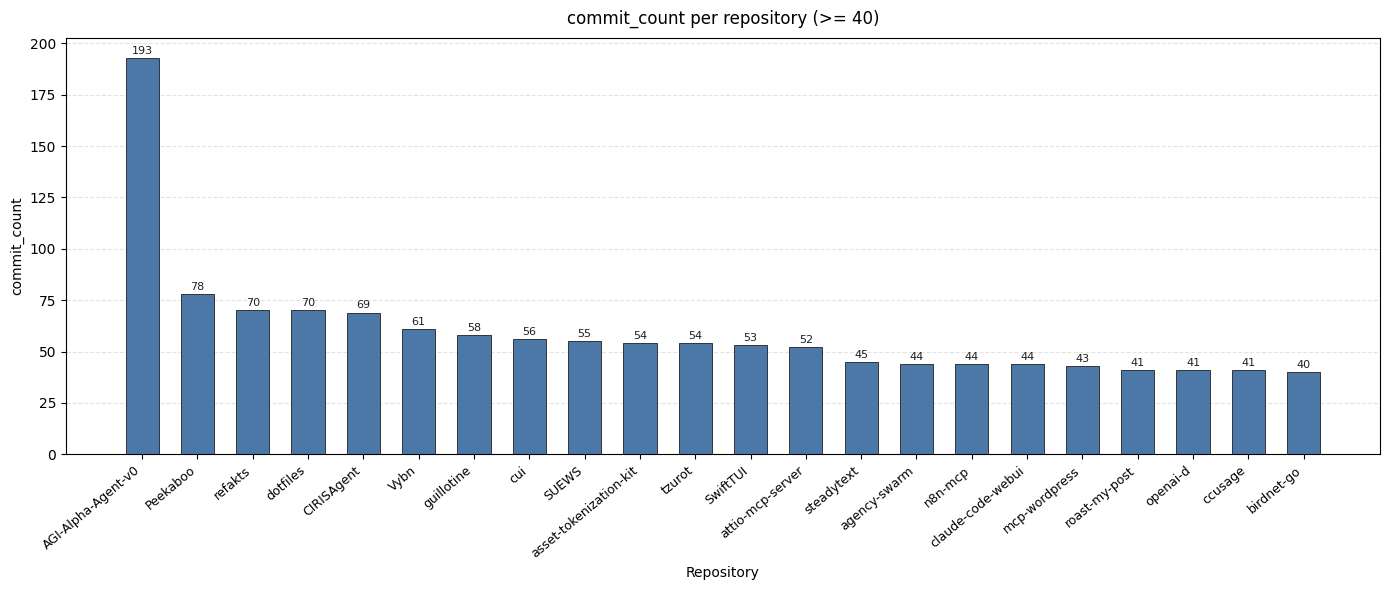

In [13]:
import matplotlib.pyplot as plt

repo_commits_filtered = repo_commits[repo_commits["commit_count"] >= 40].reset_index(drop=True)

print(f'{"Repository":<55} {"commit_count":>12}')
print("-" * 69)
for _, row in repo_commits_filtered.iterrows():
    print(f'{row["repo_id"]:<55} {row["commit_count"]:>12}')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    range(len(repo_commits_filtered)),
    repo_commits_filtered["commit_count"],
    color="#4c78a8", edgecolor="#1f1f1f", linewidth=0.6, width=0.6,
)
for rect, value in zip(bars, repo_commits_filtered["commit_count"]):
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 1,
        str(value),
        ha="center", va="bottom", fontsize=8, color="#1f1f1f",
    )
ax.set_title("commit_count per repository (>= 40)", pad=10)
ax.set_xlabel("Repository")
ax.set_ylabel("commit_count")
ax.set_xticks(range(len(repo_commits_filtered)))
ax.set_xticklabels(repo_commits_filtered["repo_id"].str.split("/").str[1], rotation=40, ha="right", fontsize=9)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


### Distribuzione del commit_count per repository — Histogram e CDF

Visualizzazione della distribuzione del `commit_count` per scegliere in modo informato la soglia di filtraggio.

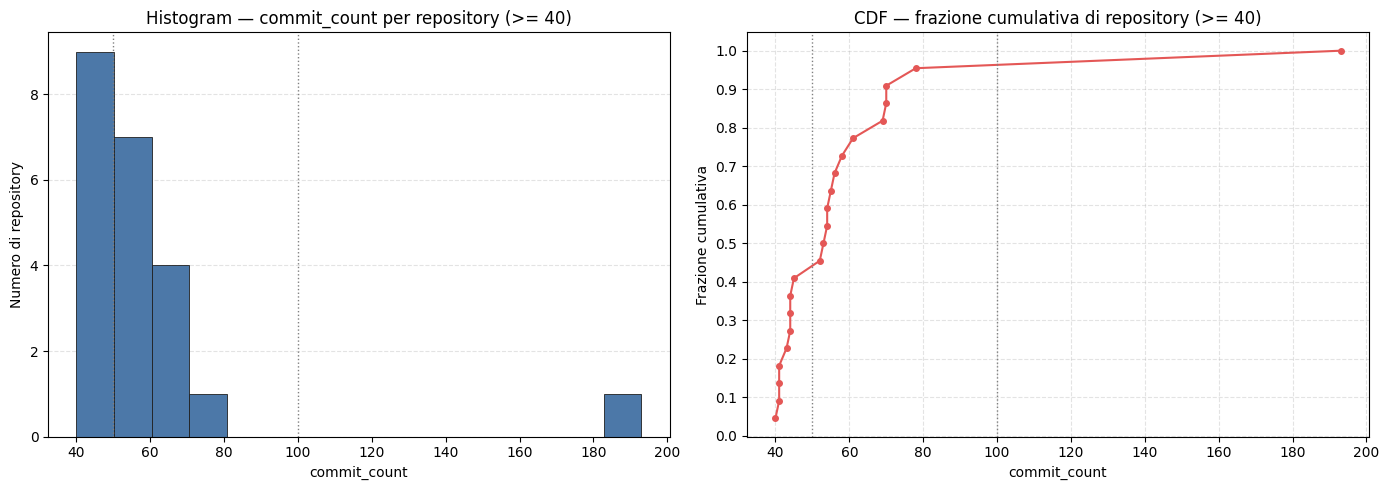


Statistiche (repo con commit_count >= 40):
  min:    40
  median: 53
  mean:   59.4
  max:    193
  repo con commit_count >=  40: 22/22
  repo con commit_count >=  50: 13/22
  repo con commit_count >=  75: 2/22
  repo con commit_count >= 100: 1/22


In [14]:
import numpy as np

values = sorted(repo_commits_filtered["commit_count"].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(values, bins=15, color="#4c78a8", edgecolor="#1f1f1f", linewidth=0.6)
axes[0].set_title("Histogram — commit_count per repository (>= 40)")
axes[0].set_xlabel("commit_count")
axes[0].set_ylabel("Numero di repository")
axes[0].set_axisbelow(True)
axes[0].grid(axis="y", linestyle="--", alpha=0.35)

sorted_vals = np.sort(values)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, marker="o", color="#e45756", linewidth=1.5, markersize=4)
axes[1].set_title("CDF — frazione cumulativa di repository (>= 40)")
axes[1].set_xlabel("commit_count")
axes[1].set_ylabel("Frazione cumulativa")
axes[1].set_yticks(np.arange(0, 1.1, 0.1))
axes[1].set_axisbelow(True)
axes[1].grid(linestyle="--", alpha=0.35)

for ax in axes:
    for v in [50, 100]:
        ax.axvline(v, color="gray", linestyle=":", linewidth=1, label=f"soglia={v}")

plt.tight_layout()
plt.show()

print(f"\nStatistiche (repo con commit_count >= 40):")
print(f"  min:    {min(values)}")
print(f"  median: {int(np.median(values))}")
print(f"  mean:   {np.mean(values):.1f}")
print(f"  max:    {max(values)}")
for soglia in [40, 50, 75, 100]:
    n = sum(1 for v in values if v >= soglia)
    print(f"  repo con commit_count >= {soglia:>3}: {n}/{len(values)}")


### Filtraggio del dataset in base alla soglia scelta

Vengono mantenute solo le repository con `commit_count` maggiore o uguale alla soglia definita.

In [15]:
SOGLIA = 50

repos_valide = set(repo_commits[repo_commits["commit_count"] >= SOGLIA]["repo_id"])
print(f"Soglia: {SOGLIA}")
print(f"Repository che superano la soglia: {len(repos_valide)}/{len(repo_commits)}")
print()
for _, row in repo_commits[repo_commits["commit_count"] >= SOGLIA].iterrows():
    print(f'  {row["repo_id"]:<50} {row["commit_count"]:>5}')

df_clean["_repo_key"] = df_clean["repository_owner"] + "/" + df_clean["repository_name"]
df_filtered = df_clean[df_clean["_repo_key"].isin(repos_valide)].drop(columns=["_repo_key"]).copy()

print(f"\nRighe nel dataset prima del filtro: {len(df_clean)}")
print(f"Righe nel dataset dopo il filtro:  {len(df_filtered)}")

Soglia: 50
Repository che superano la soglia: 13/1897

  MontrealAI/AGI-Alpha-Agent-v0                        193
  steipete/Peekaboo                                     78
  devill/refakts                                        70
  baleen37/dotfiles                                     70
  CIRISAI/CIRISAgent                                    69
  zoedolan/Vybn                                         61
  evmts/guillotine                                      58
  BMPixel/cui                                           56
  UMEP-dev/SUEWS                                        55
  settlemint/asset-tokenization-kit                     54
  lbds137/tzurot                                        54
  bannzai/SwiftTUI                                      53
  kesslerio/attio-mcp-server                            52

Righe nel dataset prima del filtro: 2179
Righe nel dataset dopo il filtro:  14


Salvataggio delle modifiche effettuate in un nuovo dataset

In [16]:
from pathlib import Path

output_path = Path(data_path).parent / "dataset_cleaned.csv"
df_filtered.to_csv(output_path, index=False)
print(f"Saved: {output_path}")


Saved: d:\Progetti\ContextWare\data-manipulation\dataset\dataset_cleaned.csv
